# Predictive Sales Analysis — Corrected Notebook
**AIMMS Consulting** · *Let's Color The Daring Dreams Together*

**What changed from the first version**
1. `Date` was label-encoded (turning dates into arbitrary integers). It is now parsed as a real date and used for calendar features.
2. `Revenue` was predicted from `Price`, `Quantity_Sold` and `Discount`, but `Revenue = Price × Quantity × (1 − Discount)` exactly. That is **target leakage**, so the old ~99.9% R² was meaningless.
3. The train/test split was random. For time series it must be **chronological**.
4. Models were never compared with a naive baseline. They are now.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
plt.rcParams.update({'figure.figsize':(9,3.6),'axes.spines.top':False,'axes.spines.right':False})
NAVY, GOLD = '#0C2450', '#F5A10F'

## 1. Load and validate

In [2]:
import os
PATH = next(p for p in ('Predictive_Sales_Data.csv','../data/Predictive_Sales_Data.csv') if os.path.exists(p))
df = pd.read_csv(PATH)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)
print(df.shape, '| missing values:', int(df.isna().sum().sum()))
print('Date range:', df.Date.min().date(), 'to', df.Date.max().date())
print('Rows per day:', df.Date.value_counts().max(), '(one record per calendar day)')
df.describe().T.round(2)

(9251, 9) | missing values: 0
Date range: 2022-01-01 to 2047-04-30
Rows per day: 1 (one record per calendar day)


,count,mean,min,25%,50%,75%,max,std
Date,9251,2034-08-31 00:00:00,2022-01-01 00:00:00,2028-05-01 12:00:00,2034-08-31 00:00:00,2040-12-29 12:00:00,2047-04-30 00:00:00,NaN
Store_ID,9251.0,10.050589,1.0,5.0,10.0,15.0,19.0,5.506324
Product_ID,9251.0,149.175332,100.0,124.0,149.0,174.0,199.0,28.810861
Price,9251.0,258.00005,10.02,136.6,259.29,378.28,499.95,141.270088
Quantity_Sold,9251.0,9.958923,1.0,5.0,10.0,15.0,19.0,5.434886
Discount,9251.0,0.1494,0.0,0.07,0.15,0.23,0.3,0.08694
Customer_Rating,9251.0,2.996735,1.0,2.0,3.0,4.0,5.0,1.156463
Revenue,9251.0,2198.595626,7.622,670.6277,1663.116,3323.5412,9355.7178,1868.188329


**Finding:** one record per day from 2022 to 2047. Dates after today cannot be observed sales, so the dataset is **synthetic** and is used here to demonstrate method.

## 2. Leakage check

In [3]:
recon = df.Price * df.Quantity_Sold * (1 - df.Discount)
print('Max |Revenue - Price*Qty*(1-Discount)| =', float((recon - df.Revenue).abs().max()))

Max |Revenue - Price*Qty*(1-Discount)| = 1.8189894035458565e-12


Revenue is fully determined by three other columns, so a model given those columns is only re-doing arithmetic. Demonstration:

In [4]:
X = df[['Store_ID','Product_ID','Price','Quantity_Sold','Discount','Customer_Rating']].assign(Category=df.Category.astype('category').cat.codes)
y = df.Revenue
Xa,Xb,ya,yb = train_test_split(X,y,test_size=.2,random_state=42)
leaky = RandomForestRegressor(random_state=42).fit(Xa,ya)
print(f'Original approach (leaky) R2 = {r2_score(yb, leaky.predict(Xb)):.4f}')
Xn = X.drop(columns=['Price','Quantity_Sold','Discount'])
Xa,Xb,ya,yb = train_test_split(Xn,y,test_size=.2,random_state=42)
clean = RandomForestRegressor(random_state=42).fit(Xa,ya)
print(f'Same model without leaking columns R2 = {r2_score(yb, clean.predict(Xb)):.4f}')

Original approach (leaky) R2 = 0.9988


Same model without leaking columns R2 = -0.1853


The near-perfect score was arithmetic, not prediction. Without the leaking columns, R² is **below zero**.

## 3. Exploratory analysis

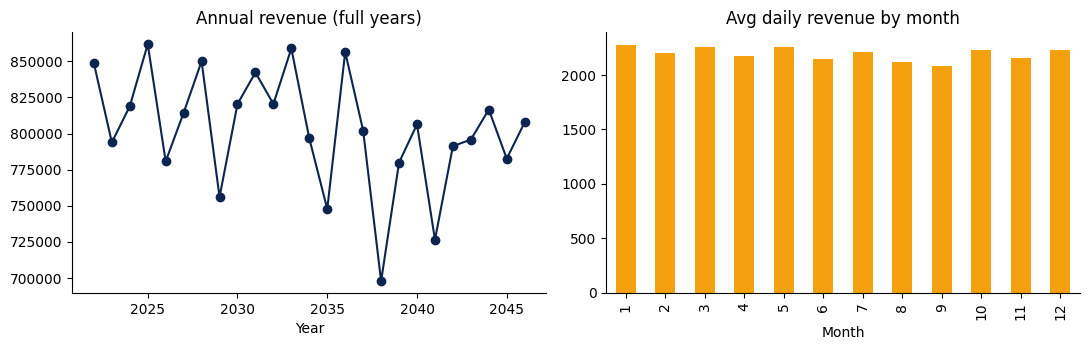

                revenue  units  avg_rating
Category                                  
Clothing     5100571.83  23298        3.00
Electronics  5017349.10  22853        3.01
Furniture    5156243.37  23304        2.96
Grocery      5065043.84  22675        3.03


In [5]:
df['Year']=df.Date.dt.year; df['Month']=df.Date.dt.month
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
df[df.Year<2047].groupby('Year').Revenue.sum().plot(ax=ax[0],color=NAVY,marker='o'); ax[0].set_title('Annual revenue (full years)')
df.groupby('Month').Revenue.mean().plot.bar(ax=ax[1],color=GOLD); ax[1].set_title('Avg daily revenue by month')
plt.tight_layout(); plt.show()
print(df.groupby('Category').agg(revenue=('Revenue','sum'),units=('Quantity_Sold','sum'),avg_rating=('Customer_Rating','mean')).round(2))

,avg_revenue,avg_units
Discount,,
0-5%,2595.28,10.05
5-10%,2407.18,9.91
10-15%,2200.30,10.02
15-20%,2129.23,9.94
20-25%,1934.74,9.97
25-30%,1833.18,9.85


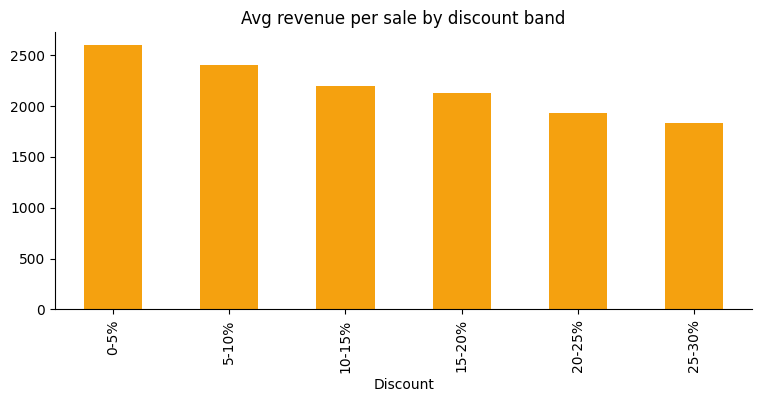

In [6]:
bands=pd.cut(df.Discount,[-.01,.05,.1,.15,.2,.25,.3],labels=['0-5%','5-10%','10-15%','15-20%','20-25%','25-30%'])
t=df.groupby(bands).agg(avg_revenue=('Revenue','mean'),avg_units=('Quantity_Sold','mean')).round(2); display(t)
t.avg_revenue.plot.bar(color=GOLD,title='Avg revenue per sale by discount band'); plt.show()

**Finding:** units per sale stay near 10 at every discount level, but revenue per sale falls about 30% from the lowest to the highest band. Discounts give away margin without adding volume.

## 4. Forecasting daily revenue (no leakage, chronological split)

Features use only the past: lags, rolling means and calendar fields. Train on the first 80% of days, test on the last 20%.

In [7]:
s = df[['Date','Revenue']].copy()
for l in (1,7,30): s[f'lag{l}'] = s.Revenue.shift(l)
s['roll7']=s.Revenue.shift(1).rolling(7).mean(); s['roll30']=s.Revenue.shift(1).rolling(30).mean()
s['dow']=s.Date.dt.dayofweek; s['month']=s.Date.dt.month; s['doy']=s.Date.dt.dayofyear
s=s.dropna().reset_index(drop=True)
F=[c for c in s.columns if c not in ('Date','Revenue')]
cut=int(len(s)*.8); tr,te=s[:cut],s[cut:]
print('Train:',tr.Date.min().date(),'->',tr.Date.max().date(),'| Test:',te.Date.min().date(),'->',te.Date.max().date())

Train: 2022-01-31 -> 2042-04-11 | Test: 2042-04-12 -> 2047-04-30


In [8]:
rows=[]
def score(name,p):
    rows.append({'model':name,'R2':r2_score(te.Revenue,p),'MAE':mean_absolute_error(te.Revenue,p),'RMSE':np.sqrt(mean_squared_error(te.Revenue,p))})
score('Baseline: training mean', np.full(len(te),tr.Revenue.mean()))
score('Baseline: yesterday (naive)', te.lag1)
score('Baseline: same day last week', te.lag7)
ridge=Ridge().fit(tr[F],tr.Revenue); score('Ridge regression', ridge.predict(te[F]))
rf=RandomForestRegressor(300,min_samples_leaf=20,random_state=42,n_jobs=-1).fit(tr[F],tr.Revenue); score('Random Forest', rf.predict(te[F]))
res=pd.DataFrame(rows).set_index('model').round(4); display(res)

,R2,MAE,RMSE
model,,,
Baseline: training mean,-0.0000,1540.5080,1894.8663
Baseline: yesterday (naive),-1.0886,2112.2425,2738.4506
Baseline: same day last week,-0.9820,2030.1896,2667.6252
Ridge regression,-0.0014,1542.6469,1896.2238
Random Forest,0.0001,1541.5064,1894.7222


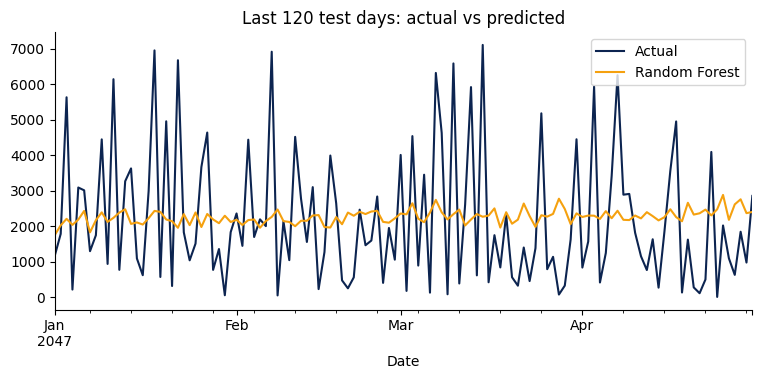

Autocorrelation lag1 / lag7: -0.0001 / 0.0006


In [9]:
te2=te.assign(pred=rf.predict(te[F])).set_index('Date')
te2.Revenue.tail(120).plot(color=NAVY,label='Actual'); te2.pred.tail(120).plot(color=GOLD,label='Random Forest')
plt.legend(); plt.title('Last 120 test days: actual vs predicted'); plt.show()
print('Autocorrelation lag1 / lag7:', round(s.Revenue.autocorr(1),4), '/', round(s.Revenue.autocorr(7),4))

## 5. Conclusions
- **The original ~99.9% R² was leakage.** Corrected, no model beats simply predicting the historical mean (R² ≈ 0).
- **Daily revenue is unpredictable in this dataset.** Autocorrelation is ≈ 0, there is no trend or seasonality, and calendar or lag features add nothing.
- **A sound forecast on this data is flat** at roughly the historical daily average, with wide uncertainty.
- **The actionable finding is descriptive, not predictive:** discounts cut revenue per sale about 30% with no gain in units.
- On real sales data, expect lags, seasonality, promotions and holidays to carry signal. This notebook's structure (chronological split, baselines, no leakage) is the template to reuse.